# Bill History

This is bills since homeownership.

## Import packages

In [31]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from datetime import datetime

## Load dataset

In [32]:
# Creating the table in dataframe from a csv file
df_raw = pd.read_csv(r"c:\Users\Clair\Documents\Code Development\Python Local\personal_finance\Bills.csv")

In [33]:
# Summary of the table
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            320 non-null    object 
 1   Month           320 non-null    int64  
 2   Category        320 non-null    object 
 3   Payment_for     320 non-null    object 
 4   Payment_to      320 non-null    object 
 5   Payment_from    320 non-null    object 
 6   Payment_amount  320 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 17.6+ KB


In [34]:
# Checking for null values
df_raw.isnull().values.any()

False

## Copy data

In [35]:
import pandas as pd

# Make a copy of the DataFrame
df_copy = df_raw.copy()

# Convert the "Date" column to datetime format
df_copy["Date"] = pd.to_datetime(df_copy["Date"])

# Preview column types and first few rows
print(df_copy.dtypes, '\n')
print(df_copy.head(2))

Date              datetime64[ns]
Month                      int64
Category                  object
Payment_for               object
Payment_to                object
Payment_from              object
Payment_amount           float64
dtype: object 

        Date  Month   Category        Payment_for Payment_to   Payment_from  \
0 2023-01-01      1  Insurance     Auto Insurance       USAA  Checking 5868   
1 2023-01-01      1  Insurance  Renters Insurance       USAA  Checking 5868   

   Payment_amount  
0           74.57  
1            9.23  


## Clean/modify data

In [36]:
# Extract the year and create a new "Year" column
df_copy["Year"] = df_copy["Date"].dt.year

# Filter data for the year 2025
df_2025 = df_copy[df_copy["Year"] == 2025]
df_2024 = df_copy[df_copy["Year"] == 2024]
df_2023 = df_copy[df_copy["Year"] == 2023]

# Display the filtered DataFrame
df_2025.head()

# Converting the (amount) string to float
df_2025["Payment_amount"] = df_2025["Payment_amount"].astype(float)
print(df_2025.dtypes,'\n')

Date              datetime64[ns]
Month                      int64
Category                  object
Payment_for               object
Payment_to                object
Payment_from              object
Payment_amount           float64
Year                       int32
dtype: object 



C:\Users\Clair\AppData\Local\Temp\ipykernel_25304\1377379675.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025["Payment_amount"] = df_2025["Payment_amount"].astype(float)


In [37]:
# Extremes
Cheap = df_2025['Payment_amount'].min()
Expensive = df_2025['Payment_amount'].max()
Paid = df_2025['Payment_amount'].sum().round(2)

print(f'Most cheap payment:\n $',Cheap,'\n')
print(f'Most expensive payment:\n $',Expensive,'\n')
print(f'Amount paid toward sustaining oneself thus far:\n $',Paid,'\n')


Most cheap payment:
 $ 0.99 

Most expensive payment:
 $ 1797.15 

Amount paid toward sustaining oneself thus far:
 $ 26726.78 



In [38]:
# Basic stats by service
print('The amount of money I paid:')
Payment_for_group = df_2025.groupby(['Category']).agg({'Payment_amount': ['min', 'max', 'mean', 'median']}).round(2)
Payment_for_group.columns = ['min', 'max', 'mean', 'median']
Payment_for_group.reset_index()
Payment_for_group

The amount of money I paid:


,min,max,mean,median
Category,,,,
Bill,1.63,55.00,25.17,40.00
Insurance,112.09,1299.00,226.21,114.17
Loan,230.00,1797.15,1052.01,1781.47
Subscription,0.99,100.00,38.88,26.24
Utility,22.42,259.28,76.69,67.99


In [39]:
# Drilling down to the fluctuating payments
filters = ['Auto Insurance', 'Electricity', 'Sewer', "Water", "Dev"]
Fluctuating_payments = df_2025.query("Payment_for in @filters")
# Fluctuating_payments

In [40]:
# Basic stats by service
print('The amount of money I paid:')
Fluctuating_payments_group = Fluctuating_payments.groupby(['Payment_for']).agg({'Payment_amount': ['min', 'max', 'mean', 'median']}).round(2)
Fluctuating_payments_group.columns = ['min', 'max', 'mean', 'median']
Fluctuating_payments_group.reset_index()
Fluctuating_payments_group

The amount of money I paid:


,min,max,mean,median
Payment_for,,,,
Auto Insurance,112.09,165.97,118.93,114.17
Dev,3.58,100.00,39.01,26.24
Electricity,53.86,259.28,134.74,99.54
Sewer,28.00,163.56,57.68,28.00
Water,22.42,129.97,43.58,22.86


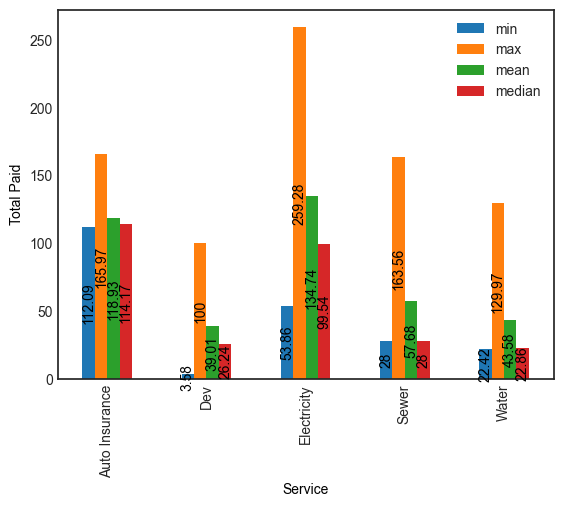

In [41]:
# Stats grouped by payment for viz
matplotlib.style.use('seaborn-v0_8-white') 
ax = Fluctuating_payments_group.plot.bar()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', rotation = 'vertical', color = 'black', fontsize = 10)

plt.xlabel('Service', size = 10, color = 'black')
plt.ylabel('Total Paid', size = 10, color = 'black')


plt.show()

In [42]:
# Count of payments by category in the last x months
Pay_count = df_2025['Category'].value_counts()
print(Pay_count)

Category
Utility         38
Subscription    24
Loan            19
Bill            16
Insurance       11
Name: count, dtype: int64


<Axes: ylabel='count'>

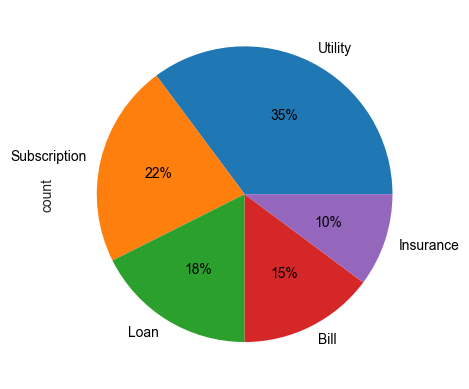

In [43]:
Pay_count.plot(kind = 'pie', y = 'Store', autopct = '%1.0f%%', textprops = {'color':'black'})

In [44]:
# Count of Payments by service in the last x months
Pay_count = df_2025['Payment_for'].value_counts()
print(Pay_count)

Payment_for
Auto Insurance    10
Electricity       10
Water             10
House Loan A      10
Hobby             10
Wifi               9
Sewer              9
House Loan B       9
Phone              9
Streaming          7
Printer            7
Dev                4
iCloud+            3
Home Insurance     1
Name: count, dtype: int64


<Axes: ylabel='count'>

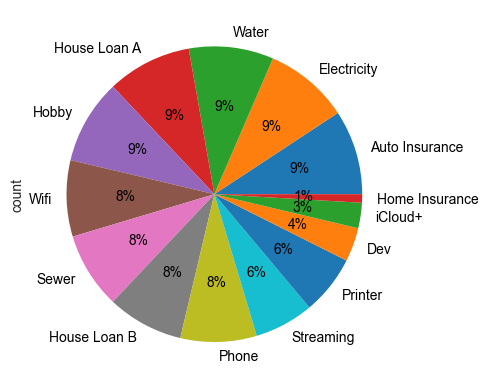

In [45]:
Pay_count.plot(kind = 'pie', y = 'Store', autopct = '%1.0f%%', textprops = {'color':'black'})

### Total

#### Monthly

In [46]:
# Spending per month
Monthly_split_total = df_2025.groupby('Month')['Payment_amount'].sum()
Monthly_split_total

Month
1     2654.88
2     4172.86
3     2979.78
4     2610.54
5     2453.29
6     2368.94
7     2462.68
8     2474.40
9     2470.30
10    2079.11
Name: Payment_amount, dtype: float64

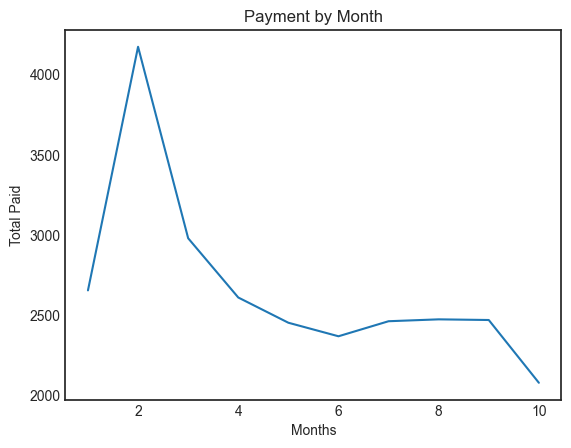

In [47]:
Monthly_split_total.plot(kind = 'line')

plt.title('Payment by Month')
plt.xlabel('Months')
plt.ylabel('Total Paid')

plt.show()

#### Service

In [48]:
# Total Spending by store
Payment_to_split = df_2025.groupby('Payment_to')['Payment_amount'].sum()
Payment_to_split

Payment_to
311/ JP CHTTNGA        519.13
Apple                    2.97
Digital Ocean            3.58
EPB                   1959.31
Foursquare              20.00
Google Cloud           132.47
HP                      12.73
High Point             673.97
Hulu                     2.18
Kraft                 2460.00
Netflix                 93.02
PBS WTCI Passport        5.00
TN American Water      435.85
UHM                  17918.24
USAA                  2488.33
Name: Payment_amount, dtype: float64

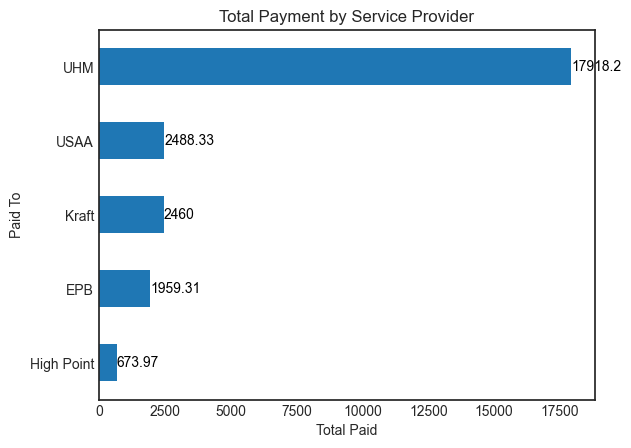

In [49]:
# sort the values in desc order so the barh will be most to least
# displaying only the top 5
Store_split = Payment_to_split.sort_values(ascending=True).tail(5)
ax = Store_split.plot.barh()
for container in ax.containers:
    #ax.bar_label(container, label_type = 'center', color = 'black', fontsize = 10)
    ax.bar_label(container, color = 'black', fontsize = 10)

plt.title('Total Payment by Service Provider')
plt.xlabel('Total Paid')
plt.ylabel('Paid To')


plt.show()